# (TP2) — Parte de Outliers y análisis multivariado: Buy to Rent en CABA

**Unidad:** publicación, no inmueble único ni transacción. **Corte:** scraping 14–17/08/2026; delitos 2023–2025.

Este notebook complementa `EDA_inicial.ipynb`: no repite su diccionario ni sus 25 distribuciones. Revisa anomalías, resume variables decisivas, compara relaciones y combina atributos físicos y entorno con una lectura de inversión. Se revisaron previamente el EDA, `README.md` y `data/processed/dataframefinal.csv`.

**Compromiso de conservación:** todas las filas permanecen en `df_original`; los tratamientos son por variable en una copia en memoria. No se exportan datasets, gráficos ni rankings y no se alteran fuentes. Los extremos estadísticos no se eliminan automáticamente. Los alquileres y ventas no son pares de la misma propiedad.

## 1. Reproducibilidad y trazabilidad
Ejecutar todas las celdas desde la raíz del repositorio o desde `notebooks/`. Dependencias: pandas, numpy, matplotlib, seaborn, statsmodels, IPython (y Jupyter para ejecución). La última celda registra versiones y verifica que las fuentes no cambiaron.

**Preparación del kernel (solo si faltan dependencias).** Elegir un entorno de Python con las bibliotecas anteriores. Si aparece `ModuleNotFoundError`, ejecutar en una celda temporal de Jupyter `%pip install pandas numpy matplotlib seaborn statsmodels`, reiniciar el kernel y ejecutar todo desde el inicio. `%pip` instala en el entorno del kernel seleccionado; instalar en otra terminal/Python no garantiza que ese kernel vea las dependencias. Esta indicación no ejecuta instalaciones automáticamente ni agrega archivos al repositorio.

In [1]:
from pathlib import Path
import hashlib
import sys
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', palette='colorblind')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

def lectura(texto):
    display(Markdown('**Interpretación.** ' + texto))

def sha256(ruta):
    return hashlib.sha256(ruta.read_bytes()).hexdigest()

# Solo se permiten dos puntos de inicio; ninguna ruta absoluta está codificada.
RAIZ = Path('.') if Path('data/processed/dataframe_limpio.csv').is_file() else Path('..')
RUTA = RAIZ / 'data/processed/dataframe_limpio.csv'
PROTEGIDOS = [RUTA, RAIZ / 'README.md', RAIZ / 'notebooks/EDA_inicial.ipynb']
assert all(p.is_file() for p in PROTEGIDOS), 'Ejecutar desde la raíz o notebooks/.'
HASH_INICIAL = {str(p): sha256(p) for p in PROTEGIDOS}
df_original = pd.read_csv(RUTA, low_memory=False)
df = df_original.copy(deep=True)
N = len(df)
print(f'Fuente relativa: {RUTA} | Publicaciones: {N:,} | Variables: {df.shape[1]}')
print(f'Item_ID duplicados: {df.Item_ID.duplicated().sum():,}')
print('Scraping:', df.Fecha_Scraping.min()[:10], 'a', df.Fecha_Scraping.max()[:10])
lectura('La unidad de análisis es el aviso: identificadores distintos pueden corresponder al mismo inmueble. '
        'La conservación de filas no obliga a usar cada dato en todos los cálculos.')

Fuente relativa: ../data/processed/dataframe_limpio.csv | Publicaciones: 55,582 | Variables: 111
Item_ID duplicados: 0
Scraping: 2026-08-14 a 2026-08-17


**Interpretación.** La unidad de análisis es el aviso: identificadores distintos pueden corresponder al mismo inmueble. La conservación de filas no obliga a usar cada dato en todos los cálculos.

## 2. Revisión y tratamiento de outliers
### 2.1 Criterios: imposibilidad, dato sospechoso y extremo plausible

- **Imposibles por dominio:** precio o superficie no positivos; cantidades negativas o fraccionarias de ambientes; distancias/conteos negativos; confort fuera de [0,1]. Se anula el valor, no la publicación.
- **Inconsistencia:** cubierta mayor que total. No se sabe cuál falló: ambas medidas se anulan para cálculos, conservando originales y bandera.
- **Centinelas o errores de escala presumidos:** superficies ≥10 millones de m², conteos ≥1 millón, expensas ≥1 millón USD/mes. Son órdenes de magnitud incompatibles con la unidad residencial del proyecto, no una demostración física. Se aparta el valor y se exige revisión de texto/origen. No se aplica un techo a precios positivos.
- **Antigüedad >150:** valor dudoso, no físicamente imposible; se sigue la política documentada de `Antiguedad_limpia` y se cuantifica su pérdida.
- **Expensas cero:** no imposible. Puede ser gasto inexistente en casa/PH o falta de información; se conserva el cero original y se usa solo gasto positivo validado para estimaciones de costos. No se imputa cero a faltantes.
- **Coordenadas marcadas:** se dejan las demás variables utilizables; los análisis geográficos/modelos no usan el entorno de esos avisos. El flag rectangular no prueba pertenencia al polígono de CABA.
- **Flags generales y de precio:** se auditan, pero no causan eliminación automática. Una venta barata o cara puede ser auténtica.

Los umbrales son decisiones reproducibles y revisables, no verdades del mercado. Los criterios del EDA se aprovechan, pero su afirmación de que todos los extremos restantes son mercado real requiere validación individual.

In [2]:
imposible = pd.DataFrame(index=df.index)
sospechoso = pd.DataFrame(index=df.index)
variables_positivas = ['Precio_USD', 'Superficie_Total_m2', 'Superficie_Cubierta_m2']
conteos = ['Ambientes', 'Dormitorios', 'Baños', 'Cocheras', 'Bauleras']
entorno = ['Distancia_Subte_m', 'Distancia_Hospital_m', 'Cantidad_Delitos_1000m',
           'Cantidad_Colectivos_500m', 'Distancia_Espacio_Verde_m',
           'Cantidad_Espacios_Verdes_1000m', 'Superficie_Verde_1000m_m2']
analizadas = variables_positivas + conteos + ['Expensas_USD', 'Antiguedad', 'Tasa_Confort_Amenities'] + entorno
for col in analizadas:
    s = pd.to_numeric(df_original[col], errors='coerce')
    df[col] = s
    imposible[col] = s.notna() & ~np.isfinite(s)
    sospechoso[col] = False
    if col in variables_positivas:
        imposible[col] |= s.le(0)
    elif col in conteos:
        imposible[col] |= s.lt(0) | (s.notna() & s.mod(1).ne(0))
        if col == 'Ambientes': imposible[col] |= s.eq(0)
        sospechoso[col] = s.ge(1_000_000)
    elif col == 'Tasa_Confort_Amenities':
        imposible[col] |= s.lt(0) | s.gt(1)
    else:
        imposible[col] |= s.lt(0)
    if col.startswith('Superficie_'): sospechoso[col] = s.ge(10_000_000)
    if col == 'Expensas_USD': sospechoso[col] = s.ge(1_000_000)
    if col == 'Antiguedad': sospechoso[col] = s.gt(150)
    df.loc[imposible[col] | sospechoso[col], col] = np.nan
inconsistencia = (df.Superficie_Cubierta_m2 > df.Superficie_Total_m2).fillna(False)
df.loc[inconsistencia, ['Superficie_Total_m2', 'Superficie_Cubierta_m2']] = np.nan
# El denominador válido determina el precio/m²; no se reutiliza sin auditar el KPI original.
df['Precio_m2_analisis'] = df.Precio_USD / df.Superficie_Total_m2
expensas_cero = df_original.Expensas_USD.eq(0)
df['Expensas_informadas_USD'] = df.Expensas_USD.where(
    df.Expensas_USD.gt(0) & df.Flag_Expensas_Anomalas.eq(0))
df['Antiguedad_analisis'] = df.Antiguedad.where(df.Antiguedad.between(0,150))
geo_valida = df.Flag_Coordenadas_Anomalas.eq(0) & df.Latitud.notna() & df.Longitud.notna()
df.loc[~geo_valida, entorno] = np.nan

auditoria = pd.DataFrame({'n_original_informado': df_original[analizadas].notna().sum(),
                         'n_imposible': imposible.sum(), 'n_sospechoso_escala': sospechoso.sum(),
                         'n_utilizable': df[analizadas].notna().sum()})
auditoria['%_utilizable_total'] = 100 * auditoria.n_utilizable / N
display(auditoria.round(2))
lectura(f'Hay {imposible.any(axis=1).sum():,} avisos con al menos un valor imposible y '
        f'{sospechoso.any(axis=1).sum():,} con dato de escala sospechosa; las categorías pueden superponerse. '
        f'{inconsistencia.sum():,} tienen superficies inconsistentes. La pérdida de entorno también incluye '
        f'{(~geo_valida).sum():,} coordenadas sin validación. Los conteos son por variable, no filas eliminadas.')

,n_original_informado,n_imposible,n_sospechoso_escala,n_utilizable,%_utilizable_total
Precio_USD,55582,0,0,55582,100.000
Superficie_Total_m2,55437,186,1,54977,98.910
Superficie_Cubierta_m2,54075,0,1,53801,96.800
Ambientes,55296,608,1,54687,98.390
Dormitorios,55211,0,1,55210,99.330
Baños,55295,0,1,55294,99.480
Cocheras,50378,0,1,50377,90.640
Bauleras,41877,0,1,41876,75.340
Expensas_USD,52769,0,2,52767,94.940
Antiguedad,53959,194,92,53673,96.570


**Interpretación.** Hay 986 avisos con al menos un valor imposible y 93 con dato de escala sospechosa; las categorías pueden superponerse. 273 tienen superficies inconsistentes. La pérdida de entorno también incluye 102 coordenadas sin validación. Los conteos son por variable, no filas eliminadas.

In [3]:
flags = df_original.filter(regex='^Flag_').mean().mul(100).sort_values(ascending=False).to_frame('% marcado / total')
display(flags.round(2))
ceros = pd.crosstab(df_original.Tipo_Propiedad, expensas_cero).reindex(columns=[False, True], fill_value=0)
ceros.columns = ['No cero (incluye faltantes)', 'Cero original']
ceros['% cero / tipo'] = 100 * ceros['Cero original'] / ceros.sum(axis=1)
display(ceros.round(2))
lectura(f'El flag general marca {df_original.Flag_Anomalia_General.mean():.1%} del total: '
        'filtrarlo como si equivaliera a error irrecuperable sesgaría la muestra. '
        f'Hay {expensas_cero.sum():,} ceros de expensas; su distribución por tipo aconseja '
        'verificar el texto antes de interpretarlos como gasto nulo. La tabla no identifica ceros verdaderos.')

,% marcado / total
Flag_Anomalia_General,61.920
Flag_Expensas_Anomalas,42.880
Flag_Balcon_Sin_Dato,38.720
Flag_Amenities_Anomalos,31.850
Flag_Expensas_Imputada,31.700
Flag_Rentabilidad_No_Calculable,23.600
Flag_Antiguedad_Cero_Sin_Estado,20.030
Flag_Cocheras_PH_Sin_Dato,9.360
Flag_Duplicado_Sobrante,4.320
Flag_Tipo_Propiedad_Anomalo,2.580


,No cero (incluye faltantes),Cero original,% cero / tipo
Tipo_Propiedad,,,
Casa,1016,3284,76.370
Departamento,29007,16215,35.860
PH,1739,4321,71.300


**Interpretación.** El flag general marca 61.9% del total: filtrarlo como si equivaliera a error irrecuperable sesgaría la muestra. Hay 23,820 ceros de expensas; su distribución por tipo aconseja verificar el texto antes de interpretarlos como gasto nulo. La tabla no identifica ceros verdaderos.

### 2.2 Extremos contextuales: Tukey en logaritmos
Precio, superficie y precio/m² se comparan dentro de **operación × tipo de propiedad**, nunca venta contra alquiler. Se aplica 1,5×IQR a sus logaritmos; si el grupo tiene menos de 30 valores o IQR=0, no se clasifica. No usamos Tukey en cocheras/bauleras: un IQR cero confunde presencia con anomalía. Los flags nuevos indican revisión, no fraude ni error.

In [4]:
cols_out = ['Precio_USD', 'Superficie_Total_m2', 'Precio_m2_analisis']
flags_log = pd.DataFrame(False, index=df.index, columns=cols_out)
limites = []
for clave, indices in df.groupby(['Tipo_Operacion','Tipo_Propiedad']).groups.items():
    for col in cols_out:
        s = df.loc[indices, col].dropna()
        s = s[np.isfinite(s) & s.gt(0)]
        q1, q3 = np.log(s).quantile([.25,.75])
        iqr = q3-q1
        if len(s) >= 30 and iqr > 0:
            inferior, superior = np.exp(q1-1.5*iqr), np.exp(q3+1.5*iqr)
            marcado = s.lt(inferior) | s.gt(superior)
            flags_log.loc[s.index,col] = marcado
            limites.append((*clave, col, len(s), inferior, superior, marcado.sum(), 100*marcado.mean()))
limites = pd.DataFrame(limites, columns=['Operacion','Tipo','Variable','n','Limite_bajo','Limite_alto','n_extremo','%_extremo'])
display(limites.round(2))
lectura('Los límites se adaptan a segmentos de mercado y la escala logarítmica reduce el efecto de la cola derecha. '
        'Un extremo sigue siendo plausible hasta verificar publicación y unidades; diferencias entre tipos no son errores. '
        'La regla no garantiza detectar todas las cargas equivocadas ni ser insensible a la mezcla interna de cada grupo.')

,Operacion,Tipo,Variable,n,Limite_bajo,Limite_alto,n_extremo,%_extremo
0,Alquiler,Casa,Precio_USD,120,287.260,"19,423.580",0,0.000
1,Alquiler,Casa,Superficie_Total_m2,110,46.710,"1,553.710",2,1.820
2,Alquiler,Casa,Precio_m2_analisis,110,3.560,26.680,6,5.450
3,Alquiler,Departamento,Precio_USD,4460,143.450,"3,206.080",232,5.200
4,Alquiler,Departamento,Superficie_Total_m2,4407,14.220,182.160,183,4.150
5,Alquiler,Departamento,Precio_m2_analisis,4407,5.520,32.340,147,3.340
6,Alquiler,PH,Precio_USD,363,169.680,"3,459.970",7,1.930
7,Alquiler,PH,Superficie_Total_m2,347,14.830,420.680,4,1.150
8,Alquiler,PH,Precio_m2_analisis,347,3.700,25.450,13,3.750
9,Venta,Casa,Precio_USD,4180,"59,938.820","1,299,658.470",114,2.730


**Interpretación.** Los límites se adaptan a segmentos de mercado y la escala logarítmica reduce el efecto de la cola derecha. Un extremo sigue siendo plausible hasta verificar publicación y unidades; diferencias entre tipos no son errores. La regla no garantiza detectar todas las cargas equivocadas ni ser insensible a la mezcla interna de cada grupo.

In [5]:
revision = df_original.loc[flags_log.any(axis=1) | imposible.any(axis=1) | sospechoso.any(axis=1)].copy()
revision['Motivo_revision_TP2'] = np.select(
    [imposible.any(axis=1).loc[revision.index], sospechoso.any(axis=1).loc[revision.index]],
    ['Valor imposible en alguna variable', 'Escala sospechosa / requiere texto'], default='Extremo contextual plausible')
# Ejemplos de cada categoría, no un ranking de oportunidades; IDs permiten auditoría.
ejemplos = revision.groupby('Motivo_revision_TP2', sort=True).head(3)
display(ejemplos[['Item_ID','Tipo_Operacion','Tipo_Propiedad','Precio_USD','Superficie_Total_m2',
                  'Expensas_USD','Motivo_revision_TP2']])
lectura('Los ejemplos preservan valores originales. Un aviso clasificado primero como imposible puede además '
        'tener extremos contextuales. Para resolverlo se revisan título, descripción, moneda, superficie y enlace '
        'original; aquí no se consultan publicaciones que pudieron cambiar desde el scraping.')

,Item_ID,Tipo_Operacion,Tipo_Propiedad,Precio_USD,Superficie_Total_m2,Expensas_USD,Motivo_revision_TP2
3,MLA1945603777,Venta,Departamento,"870,000.000",241.000,854.139,Extremo contextual plausible
7,MLA1587514523,Venta,Departamento,"1,076,900.000",197.000,0.000,Extremo contextual plausible
11,MLA1663047913,Venta,Departamento,"525,000.000",82.220,519.054,Extremo contextual plausible
75,MLA1696142907,Venta,Departamento,"39,500.000",0.000,42.707,Valor imposible en alguna variable
93,MLA3763499224,Venta,Departamento,"110,000.000",48.000,72.273,Valor imposible en alguna variable
117,MLA3764209700,Venta,Departamento,"107,970.000",50.000,0.000,Valor imposible en alguna variable
127,MLA1961656335,Venta,Departamento,"298,000.000",160.000,0.000,Escala sospechosa / requiere texto
241,MLA3726717140,Venta,Departamento,"68,000.000",NaN,32.852,Escala sospechosa / requiere texto
1106,MLA3726127978,Venta,Departamento,"79,000.000",40.000,49.277,Escala sospechosa / requiere texto


**Interpretación.** Los ejemplos preservan valores originales. Un aviso clasificado primero como imposible puede además tener extremos contextuales. Para resolverlo se revisan título, descripción, moneda, superficie y enlace original; aquí no se consultan publicaciones que pudieron cambiar desde el scraping.

### 2.3 Sensibilidad, no limpieza automática
Se comparan medianas manteniendo todos los valores utilizables versus apartando, **solo como escenario**, extremos contextuales de precio/m². Los tamaños de muestra y cambios relativos permiten juzgar estabilidad sin convertir el recorte en criterio principal.

In [6]:
filas=[]
for clave, grupo in df.groupby(['Tipo_Operacion','Tipo_Propiedad']):
    s=grupo.Precio_m2_analisis.dropna()
    sin=s[~flags_log.loc[s.index,'Precio_m2_analisis']]
    filas.append((*clave,len(s),len(sin),s.median(),sin.median(),100*(sin.median()/s.median()-1)))
sensibilidad=pd.DataFrame(filas,columns=['Operacion','Tipo','n_base','n_escenario','Mediana_base','Mediana_sin_extremos','Cambio_%'])
display(sensibilidad.round(2))
lectura(f'El mayor cambio absoluto en la mediana es {sensibilidad.Cambio_pct.abs().max():.2f}%.'
        if 'Cambio_pct' in sensibilidad else
        f'El mayor cambio absoluto en la mediana es {sensibilidad["Cambio_%"].abs().max():.2f}%. '
        'La mediana limita influencia; estabilidad central no implica que las colas carezcan de interés. '
        'El análisis principal conserva esos valores.')

,Operacion,Tipo,n_base,n_escenario,Mediana_base,Mediana_sin_extremos,Cambio_%
0,Alquiler,Casa,110,104,9.730,9.730,0.000
1,Alquiler,Departamento,4407,4260,12.920,12.780,-1.130
2,Alquiler,PH,347,334,10.000,10.040,0.370
3,Venta,Casa,4015,3937,"1,141.620","1,137.250",-0.380
4,Venta,Departamento,40473,39131,"2,351.350","2,345.990",-0.230
5,Venta,PH,5625,5549,"1,370.370","1,375.760",0.390


**Interpretación.** El mayor cambio absoluto en la mediana es 1.13%. La mediana limita influencia; estabilidad central no implica que las colas carezcan de interés. El análisis principal conserva esos valores.

## 3. Resumen univariado focalizado
Solo se sintetizan variables necesarias para inversión. El EDA ya desarrolla frecuencias, perfil habitacional y distribuciones extensas. Los precios de venta son capital de adquisición; los de alquiler son **mensuales**. La conversión USD existente usa 1.522 ARS/USD y no elimina incertidumbre cambiaria.

,Operacion,Variable,n,% sin dato utilizable,Media,Q1,Mediana,Q3
0,Alquiler,Precio_USD,4943,0.000,"1,210.860",459.920,624.180,"1,100.000"
1,Alquiler,Precio_m2_analisis,4864,1.600,17.820,10.450,12.640,16.220
2,Alquiler,Superficie_Total_m2,4864,1.600,84.290,38.000,50.000,77.000
3,Alquiler,Expensas_informadas_USD,3933,20.430,207.640,91.980,131.410,216.820
4,Alquiler,Antiguedad_analisis,4890,1.070,22.080,1.000,15.000,40.000
5,Venta,Precio_USD,50639,0.000,"221,946.060","95,000.000","146,000.000","240,000.000"
6,Venta,Precio_m2_analisis,50113,1.040,"4,228.790","1,571.430","2,156.430","2,804.000"
7,Venta,Superficie_Total_m2,50113,1.040,192.780,46.000,69.000,116.000
8,Venta,Expensas_informadas_USD,25000,50.630,171.020,72.270,111.700,185.280
9,Venta,Antiguedad_analisis,48783,3.670,23.870,0.000,13.000,46.000


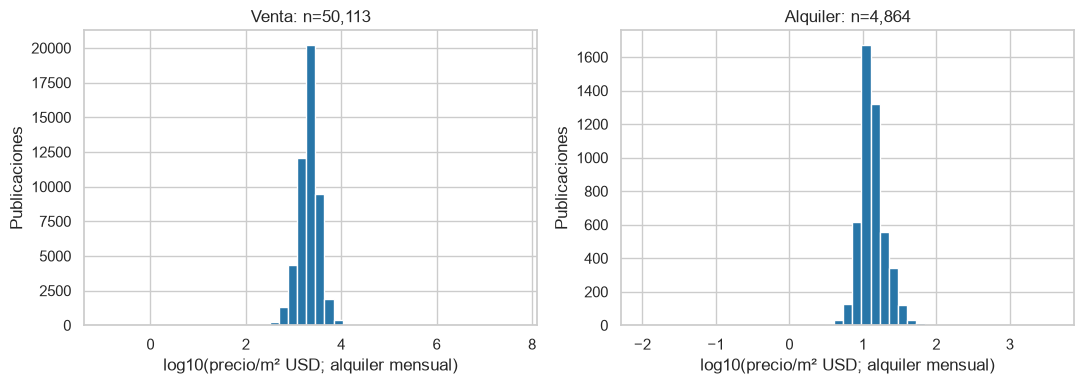

**Interpretación.** La tabla informa denominadores propios: expensas y antigüedad describen subconjuntos, no toda la oferta. Mediana e IQR son referencias más estables que la media frente a asimetría. Los histogramas muestran todos los valores utilizables en escala log10; las colas persisten y no se ocultan con percentiles. No debe compararse directamente un USD/m² de compra con un USD/m² mensual de alquiler.

In [7]:
resumen=[]
for op, grupo in df.groupby('Tipo_Operacion'):
    for col in ['Precio_USD','Precio_m2_analisis','Superficie_Total_m2','Expensas_informadas_USD','Antiguedad_analisis']:
        s=grupo[col].dropna()
        resumen.append((op,col,len(s),100*(1-len(s)/len(grupo)),s.mean(),s.quantile(.25),s.median(),s.quantile(.75)))
resumen=pd.DataFrame(resumen,columns=['Operacion','Variable','n','% sin dato utilizable','Media','Q1','Mediana','Q3'])
display(resumen.round(2))
fig,axs=plt.subplots(1,2,figsize=(11,4))
for ax,op in zip(axs,['Venta','Alquiler']):
    s=df.loc[df.Tipo_Operacion.eq(op),'Precio_m2_analisis'].dropna()
    ax.hist(np.log10(s),bins=45,color='#2876a8')
    ax.set(title=f'{op}: n={len(s):,}',xlabel='log10(precio/m² USD; alquiler mensual)',ylabel='Publicaciones')
plt.tight_layout(); plt.show()
lectura('La tabla informa denominadores propios: expensas y antigüedad describen subconjuntos, no toda la oferta. '
        'Mediana e IQR son referencias más estables que la media frente a asimetría. '
        'Los histogramas muestran todos los valores utilizables en escala log10; las colas persisten y no se ocultan con percentiles. '
        'No debe compararse directamente un USD/m² de compra con un USD/m² mensual de alquiler.')

**Lectura del resultado ejecutado.** La mediana de venta es USD 146.000, con 69 m² de superficie; la renta publicada mediana es USD 624,18 mensuales, con 50 m². Son universos distintos: dividir estas dos medianas globales produciría una comparación de composición, no el retorno de una propiedad. Solo 25.000 de 50.639 ventas (49,37%) tienen expensas positivas validadas; los costos no se conocen para la otra mitad. Las medias de precio/m² y superficie siguen siendo sensibles a valores positivos sospechosos: se priorizan medianas y auditoría de las colas.

## 4. Análisis bivariado
### 4.1 Precio y superficie; composición de oferta
Las relaciones se separan por operación. Spearman mide asociación monótona, no causalidad. El precio/m² tiene superficie en su denominador: una relación con tamaño puede ser parcialmente algebraica.

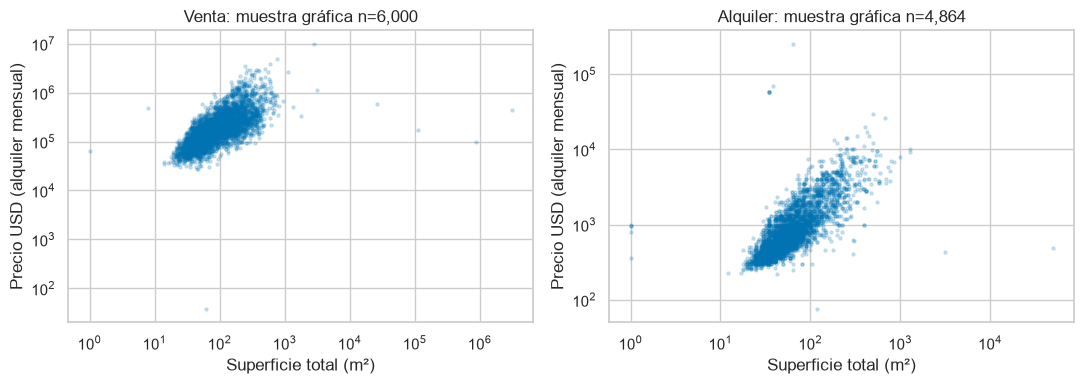

,Operacion,n_pares,rho_precio_superficie,rho_m2_superficie
0,Venta,50113,0.771,-0.255
1,Alquiler,4864,0.800,-0.061


**Interpretación.** La nube visual usa muestreo reproducible solo para legibilidad; las correlaciones usan todos los pares válidos. Se identifica cuánto acompaña el capital o alquiler al tamaño y si el precio unitario difiere con él; tipología, barrio y calidad pueden confundir estas asociaciones.

In [8]:
bivariadas=[]
fig,axs=plt.subplots(1,2,figsize=(11,4))
for ax,op in zip(axs,['Venta','Alquiler']):
    g=df.loc[df.Tipo_Operacion.eq(op),['Precio_USD','Superficie_Total_m2','Precio_m2_analisis']].dropna()
    bivariadas.append((op,len(g),g.Precio_USD.corr(g.Superficie_Total_m2,method='spearman'),
                       g.Precio_m2_analisis.corr(g.Superficie_Total_m2,method='spearman')))
    muestra=g.sample(n=min(6000,len(g)),random_state=42)
    ax.scatter(muestra.Superficie_Total_m2,muestra.Precio_USD,s=5,alpha=.18)
    ax.set(xscale='log',yscale='log',xlabel='Superficie total (m²)',ylabel='Precio USD (alquiler mensual)',title=f'{op}: muestra gráfica n={len(muestra):,}')
plt.tight_layout(); plt.show()
bivariadas=pd.DataFrame(bivariadas,columns=['Operacion','n_pares','rho_precio_superficie','rho_m2_superficie'])
display(bivariadas.round(3))
lectura('La nube visual usa muestreo reproducible solo para legibilidad; las correlaciones usan todos los pares válidos. '
        'Se identifica cuánto acompaña el capital o alquiler al tamaño y si el precio unitario difiere con él; '
        'tipología, barrio y calidad pueden confundir estas asociaciones.')

**Lectura del resultado ejecutado.** Precio y superficie tienen asociación monótona fuerte: rho=0,771 en venta y 0,800 en alquiler. Precio/m² y tamaño se relacionan negativamente en venta (−0,255), pero muy débilmente en alquiler (−0,061). Esto sugiere que el capital de adquisición no escala de forma estrictamente proporcional al área; no demuestra descuento causal por tamaño y exige controlar barrio/tipo.

n   n_m2  mediana_m2  mediana_superficie
Tipo_Operacion Tipo_Propiedad                                              
Alquiler       Casa              120    110       9.730             255.500
               Departamento     4460   4407      12.920              48.000
               PH                363    347      10.000              80.000
Venta          Casa             4180   4015   1,141.620             253.000
               Departamento    40762  40473   2,351.350              60.000
               PH               5697   5625   1,370.370             117.000

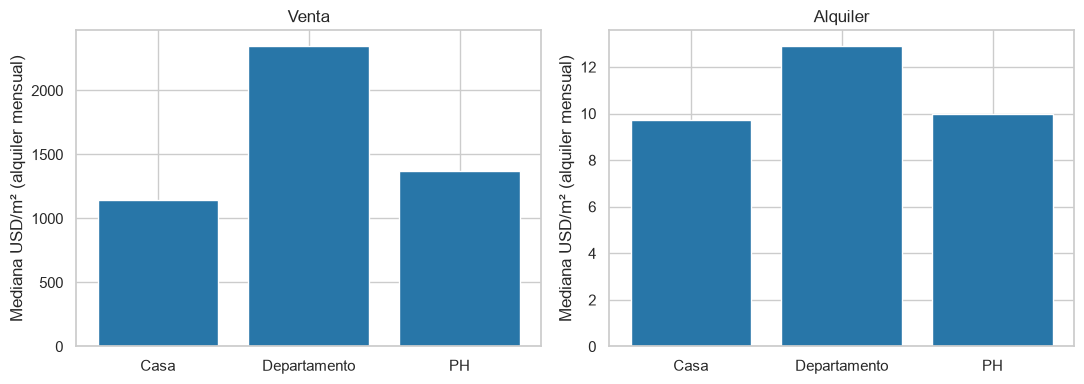

**Interpretación.** La tabla y las barras comparan medianas con cobertura explícita. Diferencias por tipo no prueban rentabilidad superior: casas/PH y departamentos tienen tamaños y barrios distintos. El análisis Buy to Rent exige comparar ambas operaciones dentro de segmentos compatibles.

In [9]:
tipos=df.groupby(['Tipo_Operacion','Tipo_Propiedad']).agg(n=('Item_ID','size'),n_m2=('Precio_m2_analisis','count'),
    mediana_m2=('Precio_m2_analisis','median'),mediana_superficie=('Superficie_Total_m2','median'))
display(tipos.round(2))
fig,axs=plt.subplots(1,2,figsize=(11,4))
for ax,op in zip(axs,['Venta','Alquiler']):
    tab=tipos.loc[op]
    ax.bar(tab.index,tab.mediana_m2,color='#2876a8')
    ax.set(title=op,ylabel='Mediana USD/m² (alquiler mensual)')
plt.tight_layout(); plt.show()
lectura('La tabla y las barras comparan medianas con cobertura explícita. Diferencias por tipo no prueban '
        'rentabilidad superior: casas/PH y departamentos tienen tamaños y barrios distintos. '
        'El análisis Buy to Rent exige comparar ambas operaciones dentro de segmentos compatibles.')

### 4.2 Entorno urbano: H4, H5 y H7
El EDA identifica **H4: transporte**, **H5: delitos** y **H7: espacios verdes/unidades familiares**. Los archivos revisados no contienen su formulación formal completa ni H1–H3/H6: se analiza la dirección de asociación pertinente, sin inventar hipótesis o dar por verificada una redacción ausente. Delitos es conteo 2023–2025, no tasa de riesgo personal. La superficie verde disponible es preferible aquí a una distancia casi saturada según el EDA.

In [10]:
entorno_corr=[]
for op,g in df.groupby('Tipo_Operacion'):
    for col in ['Distancia_Subte_m','Cantidad_Delitos_1000m','Superficie_Verde_1000m_m2','Tasa_Confort_Amenities']:
        par=g[['Precio_m2_analisis',col]].dropna()
        entorno_corr.append((op,col,len(par),par.iloc[:,0].corr(par.iloc[:,1],method='spearman')))
entorno_corr=pd.DataFrame(entorno_corr,columns=['Operacion','Predictor','n_pares','Spearman'])
display(entorno_corr.round(3))
lectura('Cada coeficiente usa su propia cobertura. Un signo positivo entre delitos y precio puede reflejar centralidad '
        'o flujo de personas, no preferencia por inseguridad; uno negativo de distancia al subte es compatible '
        'con un premio de accesibilidad, pero tampoco lo identifica causalmente. El confort mide amenidades informadas.')

,Operacion,Predictor,n_pares,Spearman
0,Alquiler,Distancia_Subte_m,4848,0.045
1,Alquiler,Cantidad_Delitos_1000m,4848,-0.073
2,Alquiler,Superficie_Verde_1000m_m2,4848,0.337
3,Alquiler,Tasa_Confort_Amenities,4864,0.473
4,Venta,Distancia_Subte_m,50028,-0.096
5,Venta,Cantidad_Delitos_1000m,50028,-0.007
6,Venta,Superficie_Verde_1000m_m2,50028,0.149
7,Venta,Tasa_Confort_Amenities,50113,0.481


**Interpretación.** Cada coeficiente usa su propia cobertura. Un signo positivo entre delitos y precio puede reflejar centralidad o flujo de personas, no preferencia por inseguridad; uno negativo de distancia al subte es compatible con un premio de accesibilidad, pero tampoco lo identifica causalmente. El confort mide amenidades informadas.

n  mediana_m2
Tipo_Operacion Familiar Verde_cuartil                  
Alquiler       False    Q1 menor        683      12.050
                        Q2              682      11.970
                        Q3              777      12.560
                        Q4 mayor        970      15.090
               True     Q1 menor        285      10.400
                        Q2              306      11.500
                        Q3              415      11.590
                        Q4 mayor        645      15.150
Venta          False    Q1 menor       5560   2,298.010
                        Q2             5407   2,342.110
                        Q3             5707   2,363.640
                        Q4 mayor       4939   2,666.670
               True     Q1 menor       7013   1,750.000
                        Q2             7097   1,850.000
                        Q3             6605   1,894.740
                        Q4 mayor       6932   2,195.090

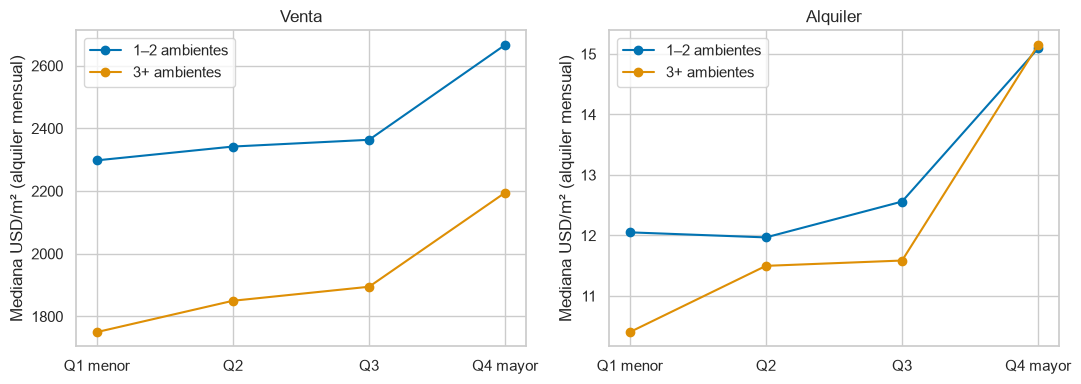

**Interpretación.** Tabla y líneas contrastan H7 descriptivamente: no hay razón para esperar monotonicidad si los cuartiles mezclan barrios y tipos. “Familiar” significa 3+ ambientes, no ocupación familiar observada. La interacción del modelo siguiente pregunta si la asociación verde-precio cambia con esa proxy, ajustando composición.

In [11]:
df['Familiar']=df.Ambientes.ge(3).where(df.Ambientes.notna()).astype('boolean')
# Cuartiles globales del entorno válido, aplicados igual a familiares/no familiares.
df['Verde_cuartil']=pd.qcut(df.Superficie_Verde_1000m_m2,4,labels=['Q1 menor','Q2','Q3','Q4 mayor'],duplicates='raise')
verde=df.groupby(['Tipo_Operacion','Familiar','Verde_cuartil'],observed=True).agg(
    n=('Precio_m2_analisis','count'),mediana_m2=('Precio_m2_analisis','median'))
display(verde.round(2))
fig,axs=plt.subplots(1,2,figsize=(11,4))
for ax,op in zip(axs,['Venta','Alquiler']):
    tab=verde.loc[op].reset_index()
    for familiar,g in tab.groupby('Familiar'):
        ax.plot(g.Verde_cuartil.astype(str),g.mediana_m2,marker='o',label='3+ ambientes' if familiar else '1–2 ambientes')
    ax.set(title=op,ylabel='Mediana USD/m² (alquiler mensual)'); ax.legend()
plt.tight_layout(); plt.show()
lectura('Tabla y líneas contrastan H7 descriptivamente: no hay razón para esperar monotonicidad si los cuartiles '
        'mezclan barrios y tipos. “Familiar” significa 3+ ambientes, no ocupación familiar observada. '
        'La interacción del modelo siguiente pregunta si la asociación verde-precio cambia con esa proxy, ajustando composición.')

**Lectura del resultado ejecutado.** En alquiler, el precio/m² mediano de 3+ ambientes pasa de USD 10,40/mes en el cuartil de menor superficie verde a USD 15,15 en el mayor; las unidades de 1–2 ambientes pasan de 12,05 a 15,09. En venta ambas categorías también aumentan hacia Q4, aunque los niveles son diferentes. La comparación visual es compatible con asociación verde-precio, pero no aísla el componente familiar: mezcla zonas y tipos. La interpretación de H7 depende del ajuste y de su sensibilidad, no de estas líneas solas.

## 5. Análisis multivariado orientado a Buy to Rent
### 5.1 Dos modelos hedónicos descriptivos
Se modela **log(precio USD)** por separado para venta y alquiler no declarado temporario. Covariables: log(superficie), ambientes, antigüedad, confort informado, log(1+distancia al subte), log(1+delitos), log(1+superficie verde), interacción verde × 3+ ambientes y efectos de barrio y tipo. Los efectos de barrio comparan dentro de barrio; no resuelven ubicación microespacial ni selección.

**No se predice rentabilidad con sus componentes**, ni se incluyen `Indice_Subvaluacion`, `Precio_Predicho_USD` o `Rentabilidad_Neta_Zona`: son KPIs construidos y generarían circularidad/fuga. El target es precio publicado, no precio de cierre ni renta efectivamente percibida. Casos completos, sin imputación automática; el sesgo de selección se cuantifica. Se retienen extremos contextuales en el modelo base; HC3 trata heterocedasticidad, no dependencia espacial.

In [12]:
df['log_precio']=np.log(df.Precio_USD)
df['log_superficie']=np.log(df.Superficie_Total_m2)
df['log_subte']=np.log1p(df.Distancia_Subte_m)
df['log_delitos']=np.log1p(df.Cantidad_Delitos_1000m)
df['log_verde']=np.log1p(df.Superficie_Verde_1000m_m2)
df['familiar_num']=df.Familiar.astype('Float64').astype(float)
variables_modelo=['log_precio','log_superficie','Ambientes','Antiguedad_analisis','Tasa_Confort_Amenities',
                  'log_subte','log_delitos','log_verde','familiar_num','Barrio_Normalizado','Tipo_Propiedad']
formula=('log_precio ~ log_superficie + Ambientes + Antiguedad_analisis + Tasa_Confort_Amenities '
         '+ log_subte + log_delitos + log_verde * familiar_num + C(Barrio_Normalizado) + C(Tipo_Propiedad)')
modelos={}; bases={}; cobertura=[]
for op in ['Venta','Alquiler']:
    elegible=df.Tipo_Operacion.eq(op) & df.Flag_Operacion_Anomala.eq(0)
    if op=='Alquiler': elegible &= ~df.Tipo_Alquiler.eq('Temporario')
    base=df.loc[elegible].dropna(subset=variables_modelo).copy()
    bases[op]=base
    modelos[op]=smf.ols(formula,data=base).fit(cov_type='HC3')
    cobertura.append((op,int(elegible.sum()),len(base),100*len(base)/elegible.sum(),
                      df.loc[elegible,'Precio_USD'].median(),base.Precio_USD.median(),modelos[op].rsquared))
cobertura=pd.DataFrame(cobertura,columns=['Operacion','n_elegible','n_completo','Cobertura_%','Mediana_elegible','Mediana_modelo','R2_in_sample'])
display(cobertura.round(3))
lectura('Las medianas de elegibles frente a casos completos permiten advertir selección por cobertura. '
        'R² es ajuste dentro de la muestra, no capacidad predictiva fuera de ella. Los alquileres de modalidad '
        'desconocida se incluyen como escenario exploratorio, no se reclasifican como tradicionales.')

,Operacion,n_elegible,n_completo,Cobertura_%,Mediana_elegible,Mediana_modelo,R2_in_sample
0,Venta,50555,47302,93.565,"146,000.000","148,000.000",0.840
1,Alquiler,4619,4387,94.977,600.000,611.038,0.789


**Interpretación.** Las medianas de elegibles frente a casos completos permiten advertir selección por cobertura. R² es ajuste dentro de la muestra, no capacidad predictiva fuera de ella. Los alquileres de modalidad desconocida se incluyen como escenario exploratorio, no se reclasifican como tradicionales.

,Operacion,Termino,beta,IC95_inf_HC3,IC95_sup_HC3
0,Venta,log_superficie,0.695,0.648,0.742
1,Venta,Ambientes,0.038,0.025,0.050
2,Venta,Antiguedad_analisis,-0.005,-0.005,-0.005
3,Venta,Tasa_Confort_Amenities,0.524,0.498,0.551
4,Venta,log_subte,0.002,-0.002,0.007
5,Venta,log_delitos,-0.037,-0.047,-0.027
6,Venta,log_verde,0.009,0.006,0.011
7,Venta,familiar_num,0.048,0.007,0.088
8,Venta,log_verde:familiar_num,0.008,0.004,0.012
9,Alquiler,log_superficie,0.510,0.358,0.662


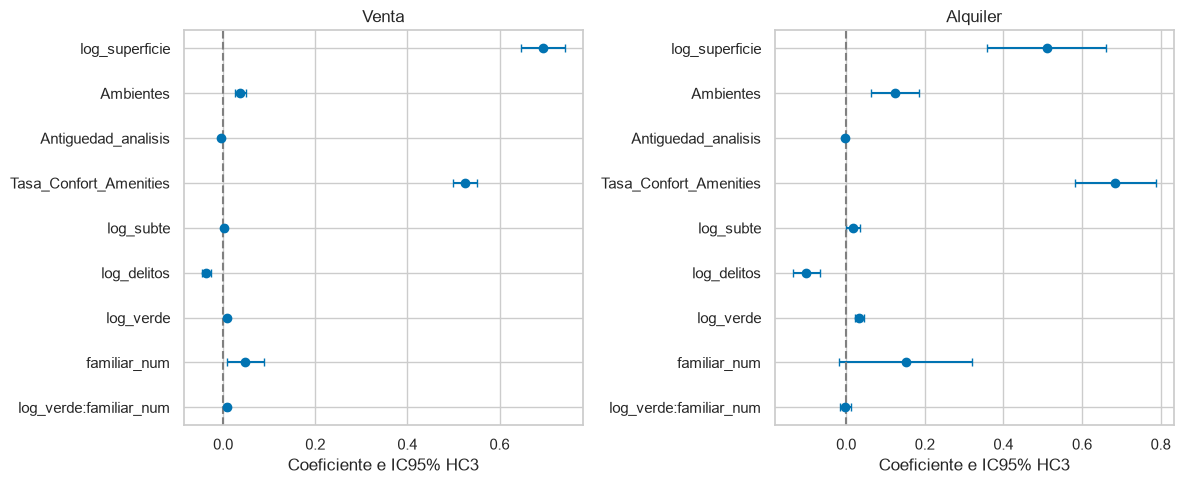

**Interpretación.** Venta: coeficiente log(superficie)=0.695; duplicar (1+distancia subte) se asocia con 0.15% de cambio de precio, manteniendo covariables fijas. Los efectos log1p son aproximaciones a elasticidad solo lejos de cero. La interacción verde es la diferencia de pendiente entre 3+ y 1–2 ambientes; el efecto para 3+ es beta_verde + beta_interacción. Los IC no incorporan dependencia espacial ni múltiples contrastes.

**Interpretación.** Alquiler: coeficiente log(superficie)=0.510; duplicar (1+distancia subte) se asocia con 1.14% de cambio de precio, manteniendo covariables fijas. Los efectos log1p son aproximaciones a elasticidad solo lejos de cero. La interacción verde es la diferencia de pendiente entre 3+ y 1–2 ambientes; el efecto para 3+ es beta_verde + beta_interacción. Los IC no incorporan dependencia espacial ni múltiples contrastes.

In [13]:
terminos=['log_superficie','Ambientes','Antiguedad_analisis','Tasa_Confort_Amenities',
          'log_subte','log_delitos','log_verde','familiar_num','log_verde:familiar_num']
coef=[]
for op,m in modelos.items():
    ci=m.conf_int()
    for t in terminos:
        coef.append((op,t,m.params[t],ci.loc[t,0],ci.loc[t,1]))
coef=pd.DataFrame(coef,columns=['Operacion','Termino','beta','IC95_inf_HC3','IC95_sup_HC3'])
display(coef.round(4))
fig,axs=plt.subplots(1,2,figsize=(12,5))
for ax,op in zip(axs,['Venta','Alquiler']):
    t=coef.loc[coef.Operacion.eq(op)].set_index('Termino').iloc[::-1]
    ax.errorbar(t.beta,t.index,xerr=[t.beta-t.IC95_inf_HC3,t.IC95_sup_HC3-t.beta],fmt='o',capsize=3)
    ax.axvline(0,color='gray',linestyle='--'); ax.set(title=op,xlabel='Coeficiente e IC95% HC3')
plt.tight_layout(); plt.show()
for op,m in modelos.items():
    lectura(f'{op}: coeficiente log(superficie)={m.params["log_superficie"]:.3f}; '
            f'duplicar (1+distancia subte) se asocia con {100*np.expm1(m.params["log_subte"]*np.log(2)):.2f}% '
            'de cambio de precio, manteniendo covariables fijas. Los efectos log1p son aproximaciones a elasticidad '
            'solo lejos de cero. La interacción verde es la diferencia de pendiente entre 3+ y 1–2 ambientes; '
            'el efecto para 3+ es beta_verde + beta_interacción. Los IC no incorporan dependencia espacial ni múltiples contrastes.')

### 5.2 Diagnóstico y sensibilidad multivariada
No basta un R²: se revisan residuos y se compara el ajuste base con un escenario sin flags contextuales. El modelo trabaja en log-precio y no debe extrapolarse a ofertas sin cobertura o propiedades fuera del universo. No se elige el escenario por su mejor significancia.

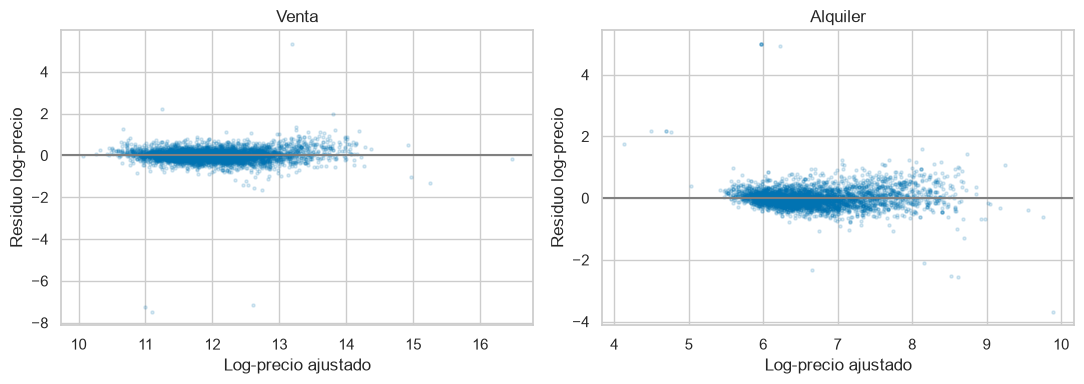

,Operacion,n,RMSE_log_in_sample,Mediana_abs_residuo,Condicion_matriz
0,Venta,47302,0.284,0.151,"4,959.708"
1,Alquiler,4387,0.334,0.153,"6,343.229"


,Operacion,Termino,n_base,n_sensibilidad,beta_base,beta_sensibilidad,Delta_beta
0,Venta,log_superficie,47302,45047,0.695,0.757,0.062
1,Venta,log_subte,47302,45047,0.002,0.002,0.000
2,Venta,log_delitos,47302,45047,-0.037,-0.007,0.030
3,Venta,log_verde:familiar_num,47302,45047,0.008,-0.007,-0.015
4,Alquiler,log_superficie,4387,4047,0.510,0.647,0.137
5,Alquiler,log_subte,4387,4047,0.016,0.009,-0.008
6,Alquiler,log_delitos,4387,4047,-0.101,-0.066,0.035
7,Alquiler,log_verde:familiar_num,4387,4047,-0.002,-0.010,-0.009


**Interpretación.** Las nubes permiten detectar residuos asimétricos, bandas o varianza no constante; la escala log no soluciona toda mala especificación. La condición de la matriz alerta sobre redundancia (ambientes, tamaño y proxy familiar están relacionados). RMSE es descriptivo, sin validación externa. La tabla muestra si signos y magnitudes dependen de extremos; no autoriza a borrar los avisos que los generan.

In [14]:
diagnosticos=[]; comparacion=[]
fig,axs=plt.subplots(1,2,figsize=(11,4))
for ax,op in zip(axs,['Venta','Alquiler']):
    m=modelos[op]; b=bases[op]
    idx=np.random.default_rng(42).choice(len(b),min(5000,len(b)),replace=False)
    ax.scatter(np.asarray(m.fittedvalues)[idx],np.asarray(m.resid)[idx],s=5,alpha=.15)
    ax.axhline(0,color='gray'); ax.set(title=op,xlabel='Log-precio ajustado',ylabel='Residuo log-precio')
    condicion=np.linalg.cond(m.model.exog)
    diagnosticos.append((op,len(b),np.sqrt(np.mean(m.resid**2)),np.median(np.abs(m.resid)),condicion))
    limpio=b.loc[~flags_log.loc[b.index].any(axis=1)]
    ms=smf.ols(formula,data=limpio).fit(cov_type='HC3')
    for t in ['log_superficie','log_subte','log_delitos','log_verde:familiar_num']:
        comparacion.append((op,t,len(b),len(limpio),m.params[t],ms.params[t],ms.params[t]-m.params[t]))
plt.tight_layout(); plt.show()
display(pd.DataFrame(diagnosticos,columns=['Operacion','n','RMSE_log_in_sample','Mediana_abs_residuo','Condicion_matriz']).round(3))
display(pd.DataFrame(comparacion,columns=['Operacion','Termino','n_base','n_sensibilidad','beta_base','beta_sensibilidad','Delta_beta']).round(4))
lectura('Las nubes permiten detectar residuos asimétricos, bandas o varianza no constante; la escala log no '
        'soluciona toda mala especificación. La condición de la matriz alerta sobre redundancia (ambientes, tamaño '
        'y proxy familiar están relacionados). RMSE es descriptivo, sin validación externa. La tabla muestra '
        'si signos y magnitudes dependen de extremos; no autoriza a borrar los avisos que los generan.')

**Resultado clave de la sensibilidad.** En venta, la interacción verde × 3+ ambientes cambia de **+0,008** en la base a **−0,007** al apartar extremos contextuales. Por eso el aparente apoyo ajustado a H7 **no es robusto** a este escenario; no se concluye un premio familiar diferencial estable. El efecto delitos permanece negativo, pero pasa de −0,037 a −0,007 en venta y de −0,101 a −0,066 en alquiler: su magnitud es sensible. La pendiente de superficie cambia de 0,695 a 0,757 en venta y de 0,510 a 0,647 en alquiler. Los residuos muestran valores muy alejados de cero y mayor dispersión en ciertas zonas del ajuste; conviene auditar publicaciones y especificación antes de usar predicciones.

## 6. Comparables y escenarios Buy to Rent
### 6.1 Rendimiento de segmentos, no de una unidad observada
Se recalculan comparables de **barrio × tipo × ambientes (1/2/3/4+)** con ≥5 ventas y ≥5 alquileres por grupo. Se requieren precio/superficie utilizables y flags de operación y tipo sin conflicto. No se impone el recorte p1–p99 del KPI original: se conserva la cola plausible. El escenario amplio excluye temporarios explícitos pero contiene alquileres desconocidos; el estricto usa solo tradicionales confirmados. Ambos se muestran.

`Renta_bruta = 12 × mediana(alquiler mensual USD) / mediana(precio venta USD)`.
Es una razón de medianas de publicaciones distintas; no tasa de retorno realizada. Las medianas pueden combinar tamaños diferentes incluso dentro del mismo número de ambientes: se informa su diferencia. `Rentabilidad_Neta_Zona` se compara solo como KPI previo, no evidencia independiente.

In [15]:
df['Ambientes_TP2']=pd.cut(df.Ambientes,[.5,1.5,2.5,3.5,np.inf],labels=['1','2','3','4+'])
claves=['Barrio_Normalizado','Tipo_Propiedad','Ambientes_TP2']
valido=(df.Precio_USD.gt(0) & df.Superficie_Total_m2.gt(0) & df.Flag_Operacion_Anomala.eq(0)
        & df.Flag_Tipo_Propiedad_Anomalo.eq(0) & df[claves].notna().all(axis=1))
ventas=df.loc[valido & df.Tipo_Operacion.eq('Venta')]
alquiler_amplio=df.loc[valido & df.Tipo_Operacion.eq('Alquiler') & ~df.Tipo_Alquiler.eq('Temporario')]
alquiler_estricto=alquiler_amplio.loc[alquiler_amplio.Tipo_Alquiler.eq('Tradicional')]

def agregar_grupos(datos):
    return datos.groupby(claves,observed=True).agg(n=('Item_ID','size'),precio=('Precio_USD','median'),
        superficie=('Superficie_Total_m2','median'),expensas=('Expensas_informadas_USD','median'),
        n_expensas=('Expensas_informadas_USD','count'))

def comparables(alquileres,minimo=5):
    v=agregar_grupos(ventas); a=agregar_grupos(alquileres)
    c=v.add_suffix('_venta').join(a.add_suffix('_alquiler'),how='inner')
    c=c.loc[c.n_venta.ge(minimo) & c.n_alquiler.ge(minimo)].copy()
    c['Bruta_%']=1200*c.precio_alquiler/c.precio_venta
    c['Diferencia_superficie_%']=100*(c.superficie_alquiler/c.superficie_venta-1)
    return c

comparables_amplios=comparables(alquiler_amplio)
comparables_estrictos=comparables(alquiler_estricto)
cover=[]
for nombre,a,c in [('Amplio no temporario explícito',alquiler_amplio,comparables_amplios),
                   ('Tradicional confirmado',alquiler_estricto,comparables_estrictos)]:
    cover.append((nombre,len(a),len(c),int(c.n_venta.sum()),int(c.n_alquiler.sum()),c['Bruta_%'].median()))
cobertura_renta=pd.DataFrame(cover,columns=['Escenario','n_alquiler_elegible','n_grupos','n_ventas_en_grupos','n_alquiler_en_grupos','Mediana_bruta_%_por_grupo'])
display(cobertura_renta.round(2))
display(comparables_amplios[['n_venta','n_alquiler','superficie_venta','superficie_alquiler','Diferencia_superficie_%','Bruta_%']].sort_values('n_alquiler',ascending=False).head(12).round(2))
lectura('La primera tabla muestra cobertura, no asigna renta a las ventas sin comparables. La segunda muestra '
        'los 12 grupos con más alquileres, no las mejores inversiones. La mediana de rentabilidades da igual peso '
        'a cada grupo, no a cada aviso; ninguna modalidad desconocida se convierte en observación tradicional. '
        'Desbalances de superficie señalan comparabilidad imperfecta y deben verificarse antes de decidir.')

,Escenario,n_alquiler_elegible,n_grupos,n_ventas_en_grupos,n_alquiler_en_grupos,Mediana_bruta_%_por_grupo
0,Amplio no temporario explícito,4351,133,36391,4012,5.900
1,Tradicional confirmado,221,12,5342,88,4.520


n_venta  n_alquiler  \
Barrio_Normalizado Tipo_Propiedad Ambientes_TP2                        
Puerto Madero      Departamento   2                  396         172   
Palermo            Departamento   2                  575         172   
Belgrano           Departamento   2                  570         149   
Palermo            Departamento   1                  469         147   
Caballito          Departamento   2                  544         139   
Recoleta           Departamento   2                  401         124   
                                  1                  387         114   
                                  3                  391         103   
Puerto Madero      Departamento   3                  457          98   
Recoleta           Departamento   4+                 783          97   
Belgrano           Departamento   1                  356          93   
Palermo            Departamento   3                  442          89   

                                                 superficie_venta  \
Barrio_Normalizado Tipo_Propiedad Ambientes_TP2                     
Puerto Madero      Departamento   2                        70.000   
Palermo            Departamento   2                        52.000   
Belgrano           Departamento   2                        53.050   
Palermo            Departamento   1                        37.000   
Caballito          Departamento   2                        51.550   
Recoleta           Departamento   2                        50.000   
                                  1                        35.000   
                                  3                        86.000   
Puerto Madero      Departamento   3                       127.000   
Recoleta           Departamento   4+                      167.000   
Belgrano           Departamento   1                        35.540   
Palermo            Departamento   3                        78.100   

                                                 superficie_alquiler  \
Barrio_Normalizado Tipo_Propiedad Ambientes_TP2                        
Puerto Madero      Departamento   2                           68.000   
Palermo            Departamento   2                           47.000   
Belgrano           Departamento   2                           48.000   
Palermo            Departamento   1                           36.000   
Caballito          Departamento   2                           43.000   
Recoleta           Departamento   2                           42.000   
                                  1                           30.860   
                                  3                           83.000   
Puerto Madero      Departamento   3                          127.500   
Recoleta           Departamento   4+                         140.000   
Belgrano           Departamento   1                           36.000   
Palermo            Departamento   3                           72.000   

                                                 Diferencia_superficie_%  \
Barrio_Normalizado Tipo_Propiedad Ambientes_TP2                            
Puerto Madero      Departamento   2                               -2.860   
Palermo            Departamento   2                               -9.620   
Belgrano           Departamento   2                               -9.520   
Palermo            Departamento   1                               -2.700   
Caballito          Departamento   2                              -16.590   
Recoleta           Departamento   2                              -16.000   
                                  1                              -11.830   
                                  3                               -3.490   
Puerto Madero      Departamento   3                                0.390   
Recoleta           Departamento   4+                             -16.170   
Belgrano           Departamento   1                                1.280   
Palermo            Departamento   3                               -7.800   


**Interpretación.** La primera tabla muestra cobertura, no asigna renta a las ventas sin comparables. La segunda muestra los 12 grupos con más alquileres, no las mejores inversiones. La mediana de rentabilidades da igual peso a cada grupo, no a cada aviso; ninguna modalidad desconocida se convierte en observación tradicional. Desbalances de superficie señalan comparabilidad imperfecta y deben verificarse antes de decidir.

**Lectura del resultado ejecutado.** El escenario amplio reúne **133 grupos**, 36.391 ventas y 4.012 alquileres, con mediana bruta por grupo **5,90% anual**. El estricto tradicional confirmado reúne **12 grupos**, 5.342 ventas y 88 alquileres, con mediana **4,52%**. La diferencia **no estima el efecto de modalidad**: cambian grupos, tamaños y zonas; tampoco convierte 5,90% en retorno del alquiler tradicional. Son magnitudes exploratorias condicionadas a cobertura y comparabilidad, no una recomendación de inversión.

### 6.2 Costos, vacancia y tipo de cambio
Rendimiento neto **condicional**: se requieren ≥5 expensas positivas validadas entre ventas del grupo. No informar expensas no equivale a costo cero. Se descuenta 1% anual de mantenimiento y se ensayan vacancia de 0/1/2 meses. Descontar todas las expensas es conservador: la proporción a cargo del propietario depende del contrato. Se omiten impuestos, comisiones, administración y costos de compra/venta; no es rentabilidad neta completa.

Para sensibilidad cambiaria se recalculan alquileres desde `Precio` y `Moneda`: 1.217,6 / 1.522 / 1.826,4 ARS/USD (±20% respecto del supuesto del proyecto), sin presentarlos como cotizaciones vigentes. Solo es escenario bruto: no se recalculan aquí gastos ni se proyecta devaluación futura.

n_venta  n_alquiler  \
Barrio_Normalizado Tipo_Propiedad Ambientes_TP2                        
Puerto Madero      Departamento   2                  396         172   
Palermo            Departamento   2                  575         172   
Belgrano           Departamento   2                  570         149   
Palermo            Departamento   1                  469         147   
Caballito          Departamento   2                  544         139   
Recoleta           Departamento   2                  401         124   
                                  1                  387         114   
                                  3                  391         103   
Puerto Madero      Departamento   3                  457          98   
Recoleta           Departamento   4+                 783          97   
Belgrano           Departamento   1                  356          93   
Palermo            Departamento   3                  442          89   

                                                 n_expensas_venta  Bruta_%  \
Barrio_Normalizado Tipo_Propiedad Ambientes_TP2                              
Puerto Madero      Departamento   2                           222    5.490   
Palermo            Departamento   2                           286    4.780   
Belgrano           Departamento   2                           245    4.190   
Palermo            Departamento   1                           192    4.560   
Caballito          Departamento   2                           311    4.380   
Recoleta           Departamento   2                           222    4.110   
                                  1                           211    5.020   
                                  3                           294    5.260   
Puerto Madero      Departamento   3                           283    4.670   
Recoleta           Departamento   4+                          691    5.580   
Belgrano           Departamento   1                           134    5.220   
Palermo            Departamento   3                           296    5.280   

                                                 Neta_condicional_vacancia_0m_%  \
Barrio_Normalizado Tipo_Propiedad Ambientes_TP2                                   
Puerto Madero      Departamento   2                                       3.710   
Palermo            Departamento   2                                       2.870   
Belgrano           Departamento   2                                       2.310   
Palermo            Departamento   1                                       2.530   
Caballito          Departamento   2                                       2.470   
Recoleta           Departamento   2                                       2.240   
                                  1                                       2.940   
                                  3                                       3.160   
Puerto Madero      Departamento   3                                       2.790   
Recoleta           Departamento   4+                                      3.330   
Belgrano           Departamento   1                                       3.190   
Palermo            Departamento   3                                       3.330   

                                                 Neta_condicional_vacancia_1m_%  \
Barrio_Normalizado Tipo_Propiedad Ambientes_TP2                                   
Puerto Madero      Departamento   2                                       3.260   
Palermo            Departamento   2                                       2.470   
Belgrano           Departamento   2                                       1.960   
Palermo            Departamento   1                                       2.150   
Caballito          Departamento   2                                       2.110   
Recoleta           Departamento   2                                       1.900   
                                  1                                       2.520   
                                  3  

,Escenario,n_grupos,Mediana_%,n_no_positivos
0,Neta_condicional_vacancia_0m_%,125,3.710,0
1,Neta_condicional_vacancia_1m_%,125,3.220,0
2,Neta_condicional_vacancia_2m_%,125,2.740,0


**Interpretación.** Solo 125 de 133 grupos permiten costo condicional con ≥5 expensas. Las dos tablas no generalizan a grupos sin datos; mayor vacancia baja el flujo por construcción. Un resultado negativo no demuestra mala inversión total: faltan valorización, negociación y condiciones reales. No se publica payback cuando el retorno es cero o negativo, ni se equipara 1/r con plazo contractual.

,ARS_por_USD_supuesto,n_grupos,Mediana_bruta_%_por_grupo
0,"1,217.600",133,7.230
1,"1,522.000",133,5.900
2,"1,826.400",133,5.020


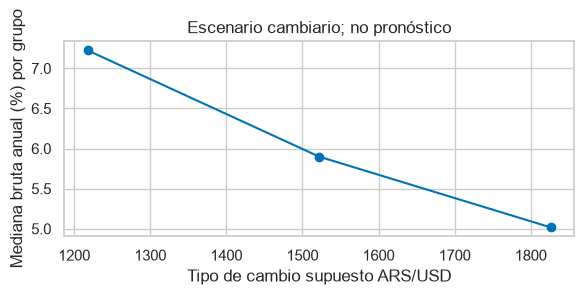

**Interpretación.** La tabla y la línea cuantifican exposición del cálculo: con alquileres en ARS, más ARS/USD reduce la renta medida en dólares mientras las ventas mayormente USD permanecen fijas. La respuesta no necesariamente es proporcional por monedas mixtas y cambios en medianas; no constituye previsión financiera.

In [16]:
costos=comparables_amplios.loc[comparables_amplios.n_expensas_venta.ge(5)].copy()
for meses in [0,1,2]:
    costos[f'Neta_condicional_vacancia_{meses}m_%']=100*((12-meses)*costos.precio_alquiler
        -12*costos.expensas_venta-.01*costos.precio_venta)/costos.precio_venta
colnet=[c for c in costos if c.startswith('Neta_')]
display(costos[['n_venta','n_alquiler','n_expensas_venta','Bruta_%']+colnet].sort_values('n_alquiler',ascending=False).head(12).round(2))
res_costos=pd.DataFrame({'Escenario':colnet,'n_grupos':len(costos),
    'Mediana_%':[costos[c].median() for c in colnet],
    'n_no_positivos':[(costos[c]<=0).sum() for c in colnet]})
display(res_costos.round(2))
lectura(f'Solo {len(costos):,} de {len(comparables_amplios):,} grupos permiten costo condicional con ≥5 expensas. '
        'Las dos tablas no generalizan a grupos sin datos; mayor vacancia baja el flujo por construcción. '
        'Un resultado negativo no demuestra mala inversión total: faltan valorización, negociación y condiciones reales. '
        'No se publica payback cuando el retorno es cero o negativo, ni se equipara 1/r con plazo contractual.')

cambio=[]
for tc in [1522*.8,1522,1522*1.2]:
    a=alquiler_amplio.copy()
    a['Precio_USD']=np.select([a.Moneda.eq('USD'),a.Moneda.eq('ARS')],[a.Precio,a.Precio/tc],default=np.nan)
    c=comparables(a)
    cambio.append((tc,len(c),c['Bruta_%'].median()))
cambio=pd.DataFrame(cambio,columns=['ARS_por_USD_supuesto','n_grupos','Mediana_bruta_%_por_grupo'])
display(cambio.round(2))
fig,ax=plt.subplots(figsize=(6,3))
ax.plot(cambio.ARS_por_USD_supuesto,cambio['Mediana_bruta_%_por_grupo'],marker='o')
ax.set(xlabel='Tipo de cambio supuesto ARS/USD',ylabel='Mediana bruta anual (%) por grupo',title='Escenario cambiario; no pronóstico')
plt.tight_layout(); plt.show()
lectura('La tabla y la línea cuantifican exposición del cálculo: con alquileres en ARS, más ARS/USD reduce la renta '
        'medida en dólares mientras las ventas mayormente USD permanecen fijas. La respuesta no necesariamente '
        'es proporcional por monedas mixtas y cambios en medianas; no constituye previsión financiera.')

**Lectura del resultado ejecutado.** Entre los **125 grupos** con costo informado suficiente, la mediana neta condicional es **3,71%**, **3,22%** y **2,74%** con 0, 1 y 2 meses de vacancia respectivamente. No corresponde restar estos valores de la mediana bruta global como si compartieran idéntico universo. La mediana bruta del escenario cambiario amplio varía de **7,23%** (1.217,6 ARS/USD) a **5,90%** (1.522) y **5,02%** (1.826,4). Esto evidencia sensibilidad de moneda, no un rango probabilístico ni un pronóstico.

## 7. Evidencia y límites de las hipótesis
Los resultados bivariados y ajustados pueden discrepar por composición. “Compatible” describe dirección, no aceptación estadística definitiva ni causalidad. La formulación original completa de la propuesta debe incorporarse en una etapa posterior para contrastar exactamente sus predicciones.

In [17]:
evidencia=[]
for op,m in modelos.items():
    for h,t,direccion in [('H4 transporte','log_subte','distancia negativa compatible con prima por cercanía'),
                           ('H5 delitos','log_delitos','conteo negativo compatible con penalización'),
                           ('H7 verde × familiar','log_verde:familiar_num','interacción positiva compatible con mayor asociación familiar')]:
        lo,hi=m.conf_int().loc[t]
        evidencia.append((h,op,m.params[t],lo,hi,'Incluye cero' if lo<=0<=hi else 'No incluye cero',direccion))
evidencia=pd.DataFrame(evidencia,columns=['Hipotesis_referida_EDA','Operacion','beta_ajustado','IC95_inf','IC95_sup','IC_descriptivo_HC3','Direccion_de_referencia'])
display(evidencia.round(4))
lectura('La tabla resume la evidencia pertinente sin convertir IC HC3 en prueba final: la dependencia espacial '
        'y la multiplicidad pueden volverlos optimistas. H7 requiere leer también la pendiente verde de base; '
        'una interacción distinta de cero no implica efecto total positivo. Para Buy to Rent importa la diferencia '
        'entre asociaciones de venta y renta, no únicamente un premio en el precio de adquisición.')

,Hipotesis_referida_EDA,Operacion,beta_ajustado,IC95_inf,IC95_sup,IC_descriptivo_HC3,Direccion_de_referencia
0,H4 transporte,Venta,0.002,-0.002,0.007,Incluye cero,distancia negativa compatible con prima por ce...
1,H5 delitos,Venta,-0.037,-0.047,-0.027,No incluye cero,conteo negativo compatible con penalización
2,H7 verde × familiar,Venta,0.008,0.004,0.012,No incluye cero,interacción positiva compatible con mayor asoc...
3,H4 transporte,Alquiler,0.016,-0.002,0.034,Incluye cero,distancia negativa compatible con prima por ce...
4,H5 delitos,Alquiler,-0.101,-0.136,-0.066,No incluye cero,conteo negativo compatible con penalización
5,H7 verde × familiar,Alquiler,-0.002,-0.015,0.012,Incluye cero,interacción positiva compatible con mayor asoc...


**Interpretación.** La tabla resume la evidencia pertinente sin convertir IC HC3 en prueba final: la dependencia espacial y la multiplicidad pueden volverlos optimistas. H7 requiere leer también la pendiente verde de base; una interacción distinta de cero no implica efecto total positivo. Para Buy to Rent importa la diferencia entre asociaciones de venta y renta, no únicamente un premio en el precio de adquisición.

**Balance de evidencia del corte analizado.**
- **H4:** la asociación bivariada distancia-precio/m² es débil y difiere por operación (venta −0,096; alquiler +0,045). Ajustando por atributos y barrio, los coeficientes de log-distancia son positivos muy pequeños y ambos IC95% HC3 incluyen cero. Este ajuste **no aporta evidencia clara de una prima por cercanía al subte**; no prueba ausencia de efecto real.
- **H5:** el conteo de delitos tiene coeficiente ajustado negativo en ambas operaciones, pero su magnitud cambia con extremos. Es asociación condicional compatible con una penalización de precios, **no efecto causal de inseguridad** ni una tasa de riesgo.
- **H7:** la interacción familiar-verde es positiva en venta base, pero cambia de signo en sensibilidad; en alquiler base el IC incluye cero. **No hay apoyo robusto a un premio diferencial familiar**, aunque el verde se asocie positivamente con precios en varias comparaciones.

Una prima en venta puede encarecer la compra tanto como una prima en alquiler aumenta ingreso. Ninguna de estas asociaciones, por sí sola, demuestra mayor rentabilidad Buy to Rent.

## 8. Conclusiones, limitaciones y próximos pasos
### Conclusiones reproducibles

In [18]:
lectura(f'1. Se mantienen las {N:,} publicaciones. Los errores de dominio y sospechas de escala se '
        'tratan por variable; los extremos plausibles se conservan, con banderas auditables.')
lectura(f'2. Los segmentos de venta y alquiler difieren en escala y cobertura. El máximo cambio de mediana '
        f'USD/m² al apartar extremos contextuales fue {sensibilidad["Cambio_%"].abs().max():.2f}%; '
        'eso apoya un resumen robusto, no la presunción de que toda cola es correcta.')
lectura(f'3. El cruce de oferta y renta deja {len(comparables_amplios)} grupos amplios y '
        f'{len(comparables_estrictos)} tradicionales confirmados con ≥5 avisos por operación. '
        'La modalidad desconocida y la comparabilidad de superficies son límites centrales para Buy to Rent.')
lectura('4. Los modelos separan atributos físicos, tipología, barrio y entorno. Las tablas de coeficientes y '
        'sensibilidad proporcionan evidencia de asociación para H4/H5/H7, no validan una estrategia de inversión '
        'ni permiten inferir efectos causales.')

**Interpretación.** 1. Se mantienen las 55,582 publicaciones. Los errores de dominio y sospechas de escala se tratan por variable; los extremos plausibles se conservan, con banderas auditables.

**Interpretación.** 2. Los segmentos de venta y alquiler difieren en escala y cobertura. El máximo cambio de mediana USD/m² al apartar extremos contextuales fue 1.13%; eso apoya un resumen robusto, no la presunción de que toda cola es correcta.

**Interpretación.** 3. El cruce de oferta y renta deja 133 grupos amplios y 12 tradicionales confirmados con ≥5 avisos por operación. La modalidad desconocida y la comparabilidad de superficies son límites centrales para Buy to Rent.

**Interpretación.** 4. Los modelos separan atributos físicos, tipología, barrio y entorno. Las tablas de coeficientes y sensibilidad proporcionan evidencia de asociación para H4/H5/H7, no validan una estrategia de inversión ni permiten inferir efectos causales.

### Limitaciones
- Muestra de publicaciones activas de una plataforma; no inventario completo, demanda, transacciones, ocupación ni días hasta alquilar. Duplicados entre avisos distintos pueden persistir.
- Precios solicitados, alquileres no emparejados y modalidad poco identificada. Los grupos con ≥5 tienen más incertidumbre que grupos grandes; no se produjeron intervalos de retorno ni ordenamiento definitivo de oportunidades.
- Faltantes y anomalías no aleatorios: casos completos, expensas positivas y cobertura geográfica pueden seleccionar segmentos. Los flags requieren auditoría de su definición y precisión.
- Amenities cero significan no informado/no detectado, no ausencia física. Antigüedad cero puede ser pozo o estreno. La proxy de unidad familiar no identifica habitantes.
- Ubicaciones aproximadas, validación rectangular y distancias en línea recta; conteos de delitos no normalizados por población, exposición o denuncia. Entorno medido antes del scraping; no riesgo actual ni probabilidad individual.
- OLS log-lineal puede omitir no linealidades, estado y calidad. Hay dependencia espacial, multicolinealidad y sesgo de selección; HC3 no los corrige. Ajuste in-sample, sin validación temporal/espacial ni interpretación causal.
- Renta bruta y neta condicional dependen de conversión, mantenimiento, comparables y quién paga expensas; no incorporan todos los costos o revalorización. Los KPIs existentes tienen filtros distintos y no son evidencia independiente.

### Próximos pasos priorizados
1. Auditar manualmente IDs marcados contra textos/origen; validar monedas, unidades, centinelas y ceros verdaderos de expensas. Solo entonces acordar correcciones persistentes con el grupo, sin sobrescribir fuentes.
2. Incorporar la redacción completa de las hipótesis; mejorar clasificación tradicional/temporario/desconocido y registrar cobertura por segmento.
3. Refinar comparables por superficie/estado, controlar duplicados de inmuebles y obtener intervalos mediante remuestreo de grupos o bloques espaciales.
4. Validar coordenadas con polígono oficial, tasas de delitos y accesibilidad caminable; evaluar no linealidad y validación por barrio/tiempo para precios, sin fuga desde KPIs derivados.
5. Construir flujos por propiedad con costos a cargo del dueño, vacancia, impuestos y compra/venta; inspeccionar oportunidades reales antes de recomendar inversiones.

## 9. Control final de integridad

In [19]:
assert len(df) == len(df_original) == N
pd.testing.assert_frame_equal(df_original, pd.read_csv(RUTA, low_memory=False))
assert {str(p): sha256(p) for p in PROTEGIDOS} == HASH_INICIAL
print('OK: fuente y archivos revisados sin modificaciones; filas conservadas; ningún export generado.')
print('Versiones:', {p: metadata.version(p) for p in ['pandas','numpy','matplotlib','seaborn','statsmodels']})
print('Python:', sys.version.split()[0])
for ruta,h in HASH_INICIAL.items(): print(ruta, h)

OK: fuente y archivos revisados sin modificaciones; filas conservadas; ningún export generado.
Versiones: {'pandas': '2.3.3', 'numpy': '2.5.3', 'matplotlib': '3.11.1', 'seaborn': '0.13.2', 'statsmodels': '0.15.0'}
Python: 3.13.12
../data/processed/dataframe_limpio.csv ca242c2659219970499c8b187f5287bf91f2c719c2da09532c7be4b8f8e4ce9a
../README.md c23ae39bfdf3a5cbec80d9e2807844f1dcb9f5ad58da129bbc49e4c070c415e6
../notebooks/EDA_inicial.ipynb 39b77b4bf1d20ccc56667f99943238f925ce1b61bc5455f7379ec431e2786df6
